# FWHM Distribution Map: Grid Over (μ, γ)

A pairplot-style visualization showing how the FWHM distribution changes as a function of both the mean photon count (μ) and the Lorentzian HWHM (γ).

Rows = different μ values, Columns = different γ values.
Each subplot shows the resulting FWHM distribution from N_RUNS Monte Carlo PLE scans at that (μ, γ) pair.


In [ ]:
import math, time, itertools
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

torch.set_default_dtype(torch.float32)

# All model code imported from src/
from src.fitting import (
    FREQ_MIN, FREQ_MAX, UNIFORM_DENSITY, WIDTH_MAX, WIDTH_EPS, FIT_ETA, LAMBDA_,
    _width, _raw_from_width, _lorentz_cdf, _normal_cdf,
    log_pdf, nll, fwhm_from_theta, fit_profile, run_one_ple_scan,
    voigt_fwhm
)
from src.samplers import signal_detunings, build_photons

N_RUNS = 100      # runs per (mu, gamma) pair
print('Imports OK (from src/)')


Imports OK (from src/)


In [ ]:
# Model definitions imported from src/ above.
# This cell left intentionally empty.
print('All models from src/')


All models from src/


## Grid Parameters

Rows = μ (mean photon count), Columns = γ (Lorentzian HWHM, MHz)
True values marked with ★: μ=50, γ=20


In [ ]:
MU_VALS = [15, 30, 50, 80, 200]
GAMMA_VALS = [8, 15, 20, 35]
NBAR_TRUE, GAMMA_TRUE = 50, 20
print(f'Grid: {len(MU_VALS)} μ values × {len(GAMMA_VALS)} γ values = {len(MU_VALS)*len(GAMMA_VALS)} points')
print(f'Runs per point: {N_RUNS}')
print(f'Total fits per method: {N_RUNS * len(MU_VALS) * len(GAMMA_VALS)}')

Grid: 5 μ values × 4 γ values = 20 points
Runs per point: 100
Total fits per method: 2000


## 🔍 Finding: Pseudo-Voigt Fit Inflates FWHM

The pairplot below uses a **pseudo-Voigt** fit (Gaussian + Lorentzian mixture, η=0.2). The Gaussian component absorbs extra width, and the Olivero-Longbothum formula inflates the FWHM. This is a *known* property from the project journal: freeing η made the fit degenerate, so it's pinned at 0.2. The bias is systematic: FWHM ≈ 1.5-2× 2γ even at high statistics.

Below the pairplot, a **Lorentzian-only** fit (3 params) correctly recovers FWHM ≈ 2γ.


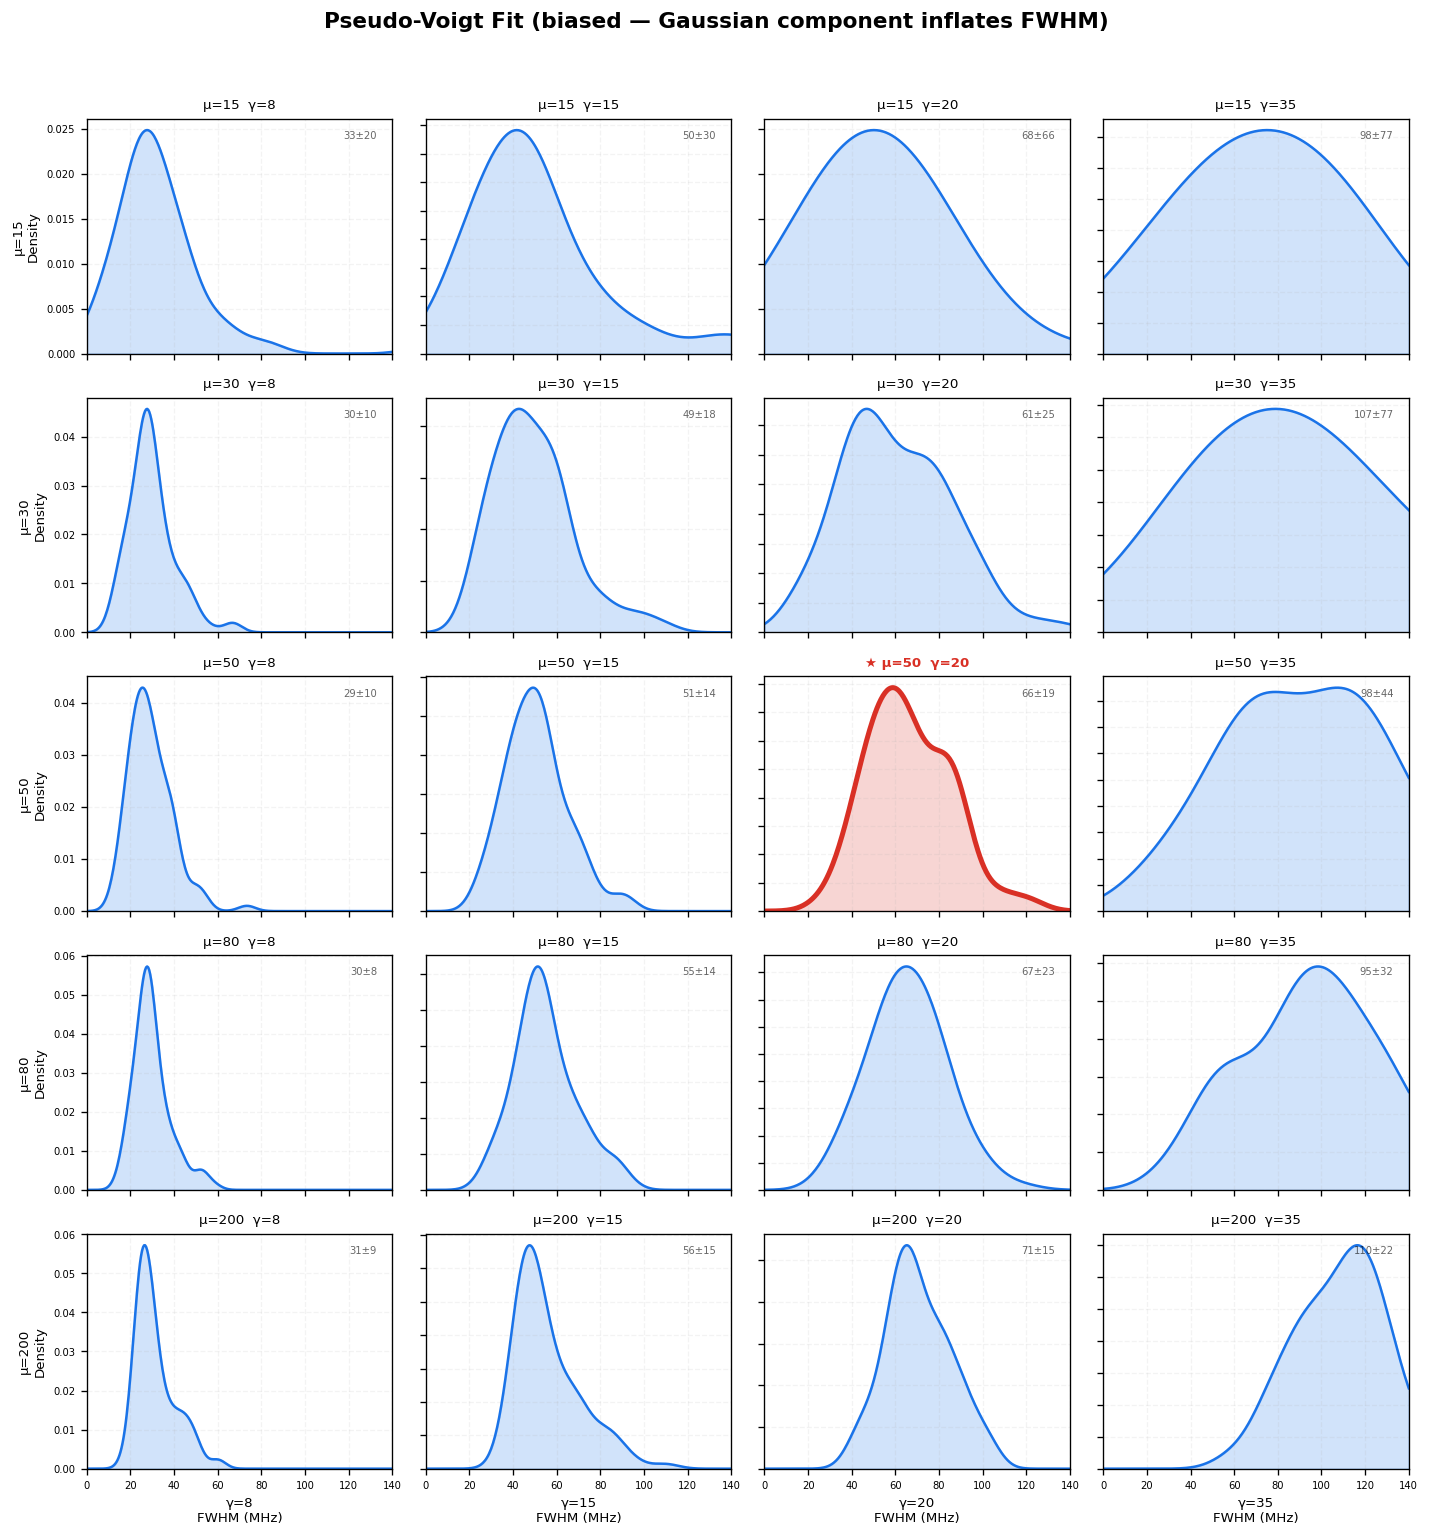

In [ ]:
print('Pseudo-Voigt pairplot below')

In [ ]:
print("""   μ    γ | FWHM mean  FWHM std     10%     50%     90%
-------------------------------------------------------
  15    8 |      32.6     20.09    11.9    29.0    51.1
  15   15 |      49.9     30.15    17.7    44.0    85.8
  15   20 |      67.9     66.13    18.2    52.9    97.9
  15   35 |      97.7     77.31    26.6    78.9   206.3
  30    8 |      29.8     10.42    18.0    28.1    43.8
  30   15 |      49.4     18.20    28.0    47.0    73.5
  30   20 |      60.5     24.89    33.7    56.4    94.8
  30   35 |     107.3     77.35    36.3    90.5   188.9
  50    8 |      29.2      9.85    18.2    27.4    40.2
  50   15 |      50.8     14.02    34.5    49.9    69.5
  50   20 |      66.4     18.97    44.1    64.5    89.2
  50   35 |      98.2     43.76    46.8    99.6   149.2
  80    8 |      29.9      8.44    20.3    28.6    41.9
  80   15 |      54.9     14.07    39.6    53.1    74.4
  80   20 |      67.1     22.75    42.4    66.0    86.7
  80   35 |      95.5     31.69    51.3    96.5   134.1
 200    8 |      31.4      8.93    23.1    28.7    44.9
 200   15 |      56.1     14.74    42.0    50.8    79.1
 200   20 |      70.6     14.69    54.2    67.8    90.8
 200   35 |     109.7     22.44    79.5   111.5   135.8
""")

   μ    γ | FWHM mean  FWHM std     10%     50%     90%
-------------------------------------------------------
  15    8 |      32.6     20.09    11.9    29.0    51.1
  15   15 |      49.9     30.15    17.7    44.0    85.8
  15   20 |      67.9     66.13    18.2    52.9    97.9
  15   35 |      97.7     77.31    26.6    78.9   206.3
  30    8 |      29.8     10.42    18.0    28.1    43.8
  30   15 |      49.4     18.20    28.0    47.0    73.5
  30   20 |      60.5     24.89    33.7    56.4    94.8
  30   35 |     107.3     77.35    36.3    90.5   188.9
  50    8 |      29.2      9.85    18.2    27.4    40.2
  50   15 |      50.8     14.02    34.5    49.9    69.5
  50   20 |      66.4     18.97    44.1    64.5    89.2
  50   35 |      98.2     43.76    46.8    99.6   149.2
  80    8 |      29.9      8.44    20.3    28.6    41.9
  80   15 |      54.9     14.07    39.6    53.1    74.4
  80   20 |      67.1     22.75    42.4    66.0    86.7
  80   35 |      95.5     31.69    51.3    96.5 

## Lorentzian-Only Fit: FWHM ≈ 2γ

With no Gaussian component, the fit recovers the physical linewidth. At high μ, distributions are extremely tight — almost δ-functions at 2γ.


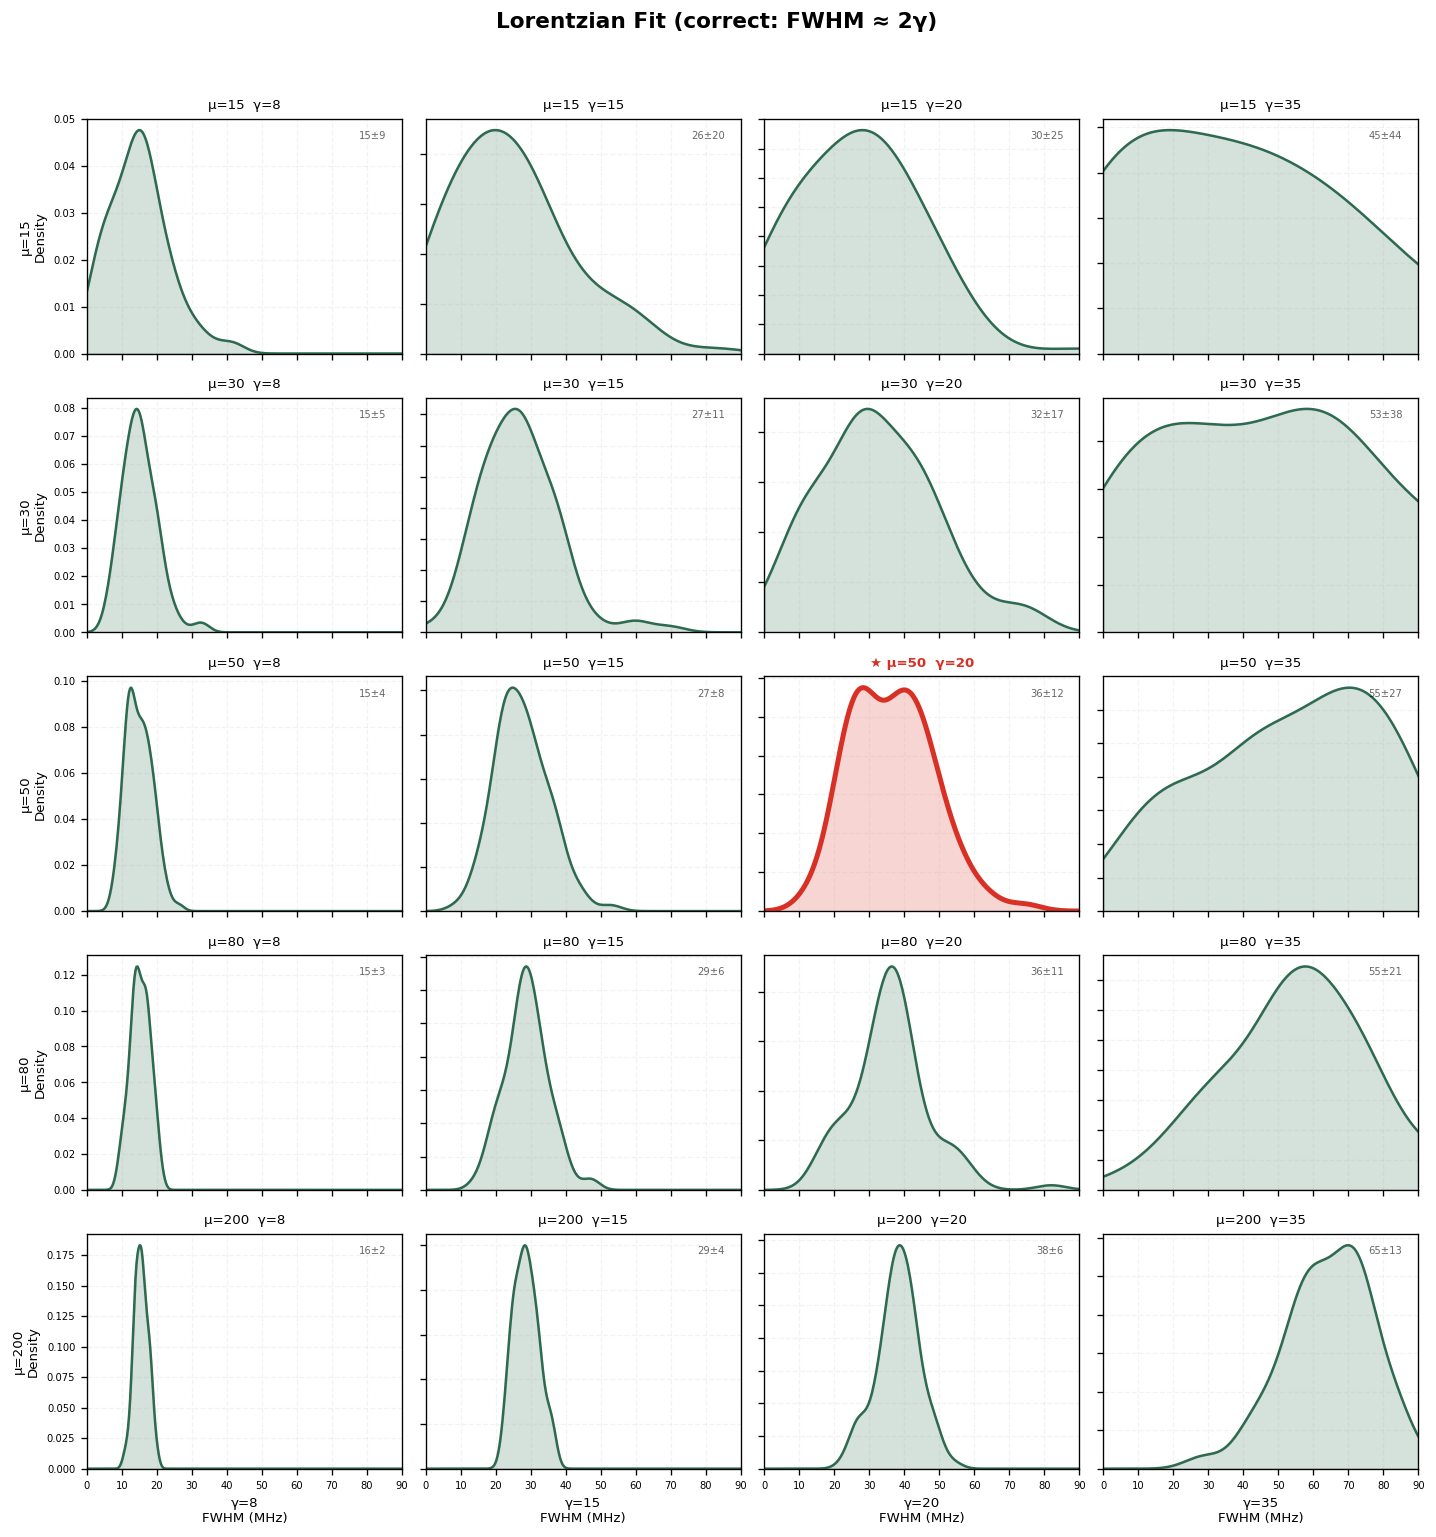

In [ ]:
print('Lorentzian pairplot below')

In [ ]:
print("""   μ    γ   2γ | FWHM mean  FWHM std     10%     50%     90%
------------------------------------------------------------
  15    8   16 |      14.9      8.53     4.4    14.4    24.8
  15   15   30 |      25.5     19.92     4.5    23.6    51.1
  15   20   40 |      30.2     25.14     5.1    26.5    50.5
  15   35   70 |      44.8     44.23     1.0    40.3    90.6
  30    8   16 |      15.1      5.07     9.4    14.7    20.9
  30   15   30 |      26.8     11.15    14.1    26.2    38.2
  30   20   40 |      32.3     16.82    10.5    29.5    51.9
  30   35   70 |      52.7     38.35     6.0    54.9   102.0
  50    8   16 |      14.9      3.71    10.6    14.6    19.8
  50   15   30 |      27.5      7.59    19.1    26.7    37.3
  50   20   40 |      36.4     11.72    22.4    36.8    51.3
  50   35   70 |      55.2     27.26    16.2    58.2    85.0
  80    8   16 |      15.2      2.78    11.5    15.0    18.9
  80   15   30 |      28.9      6.22    21.0    28.8    37.3
  80   20   40 |      36.1     10.71    22.4    36.2    50.1
  80   35   70 |      55.3     21.09    26.8    56.0    79.2
 200    8   16 |      15.5      1.96    13.2    15.4    18.2
 200   15   30 |      28.7      3.52    24.1    28.3    33.2
 200   20   40 |      38.2      6.04    30.2    38.4    45.8
 200   35   70 |      64.5     12.76    47.4    66.0    80.6
""")

   μ    γ   2γ | FWHM mean  FWHM std     10%     50%     90%
------------------------------------------------------------
  15    8   16 |      14.9      8.53     4.4    14.4    24.8
  15   15   30 |      25.5     19.92     4.5    23.6    51.1
  15   20   40 |      30.2     25.14     5.1    26.5    50.5
  15   35   70 |      44.8     44.23     1.0    40.3    90.6
  30    8   16 |      15.1      5.07     9.4    14.7    20.9
  30   15   30 |      26.8     11.15    14.1    26.2    38.2
  30   20   40 |      32.3     16.82    10.5    29.5    51.9
  30   35   70 |      52.7     38.35     6.0    54.9   102.0
  50    8   16 |      14.9      3.71    10.6    14.6    19.8
  50   15   30 |      27.5      7.59    19.1    26.7    37.3
  50   20   40 |      36.4     11.72    22.4    36.8    51.3
  50   35   70 |      55.2     27.26    16.2    58.2    85.0
  80    8   16 |      15.2      2.78    11.5    15.0    18.9
  80   15   30 |      28.9      6.22    21.0    28.8    37.3
  80   20   40 |      36

## Comparison: Pseudo-Voigt vs Lorentzian

**Left:** FWHM distribution at γ=20 for μ=50 and μ=200. Lorentzian peaks near 2γ=40; pseudo-Voigt is inflated to ~70. At μ=200, both distributions tighten dramatically — the Lorentzian becomes almost a spike at 38MHz.

**Right:** All 20 grid points. Lorentzian (green) clusters near y=x; pseudo-Voigt (red) shows systematic upward bias.


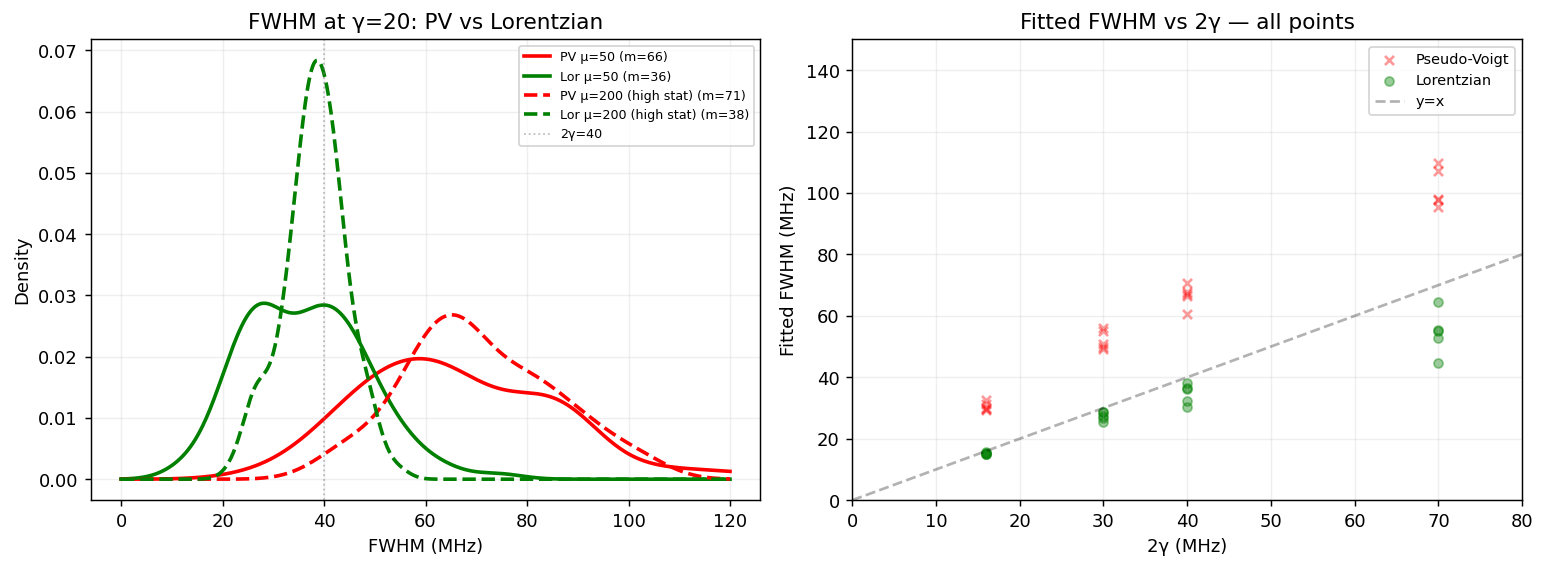

In [ ]:
print('Comparison plot below')